# Research Assistant v2 (Chatbot with summariser)

In [1]:
from decouple import AutoConfig
config = AutoConfig(search_path='./../.env')

In [2]:
import os
import openai

openai.api_key = config('OPENAI_API_KEY')
os.environ['OPENAI_API_KEY'] = openai.api_key

### Defining the LLM

In [3]:
from langchain_openai import ChatOpenAI
model_name = 'gpt-4o-mini'
llm = ChatOpenAI(
    model=model_name,
    temperature=0.0,
    max_tokens=1024
)

llm

ChatOpenAI(client=<openai.resources.chat.completions.Completions object at 0x79cb6518ec50>, async_client=<openai.resources.chat.completions.AsyncCompletions object at 0x79cb6500cb20>, root_client=<openai.OpenAI object at 0x79cb7411b5e0>, root_async_client=<openai.AsyncOpenAI object at 0x79cb6518ec80>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), max_tokens=1024)

### Defining the Graph state

State is the object that is passed between nodes in the graph.

In [4]:
from typing import TypedDict, Annotated, List
from langchain_core.messages import AnyMessage # type: ignore
from IPython.display import Image, display

#### Enabling summarisation by adding summary in the sate

In [5]:
from langgraph.graph.message import add_messages
class AgentState(TypedDict):
    input: str
    agent_outcome: List[AnyMessage]
    chat_history: Annotated[list, add_messages]
    summary: str

### Define the agent (node)

In [6]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

def research_agent(data):
    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a helpful AI assistant"
                "\nUser Query: {input}"
            ),
            MessagesPlaceholder(variable_name="chat_history"),
        ]
    )
    agent = prompt | llm
    result = agent.invoke(data)
    return {
                'agent_outcome': [result],
                'chat_history': [result],
            }

In [7]:
from langchain_core.messages import HumanMessage, RemoveMessage

def get_conv_summary(state:AgentState):
    summary = state.get("summary", "")
    if summary:
        # Summary already exist
        summary_prompt = (
            f"Summary of the conversation so far: {summary}\n\n"
            "Extend the summary considering the following new messages:"
        )
    else:
        # First summary of conversation
        summary_prompt = "Generate a summary of the following conversation:"

    messages = [HumanMessage(summary_prompt)] + state["chat_history"]
    summary = llm.invoke(messages)

    # Delete the summarised conversation
    delete_messages = [RemoveMessage(id=m.id) for m in state["chat_history"][:-2]]
    return{
        "summary": summary,
        "chat_history": delete_messages
    }


`RemoveMessage` is a reducer function to filter out messages. Here, it is used to filter out conversations which has been summarised.

### Defining the Chatbot workflow (graph)

In [8]:
from langgraph.graph import END, StateGraph

## Initialising the workflow
workflow = StateGraph(AgentState)

## Adding node (agent) to the graph (workflow)
workflow.add_node("research", research_agent)

## Setting the entry point of the graph
workflow.set_entry_point("research")

## Adding summarisation tool (as node) with the Agent in the graph
workflow.add_node("get_conv_summary", get_conv_summary)

##### Conditional edge to determine whether to end or summarise the conversation

In [9]:
def route_researcher(state: AgentState):
    messages = state["chat_history"]

    if len(messages) > 6:
        return "get_conv_summary"
    
    return END

In [10]:
workflow.add_conditional_edges("research", route_researcher)
workflow.add_edge("get_conv_summary", END)

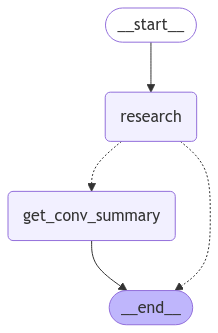

In [11]:
from langgraph.checkpoint.memory import MemorySaver

## adding memory checkpointer to the graph
memory = MemorySaver()

## Compiling the graph
app = workflow.compile(checkpointer=memory)
try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [12]:
inputs = {
    "input": "What are Small Language Models?",
}

config = {
    "configurable": {
        "thread_id": "abc123"
    }
}

inputs["chat_history"] = HumanMessage(inputs["input"])
agen_stream = app.invoke(input=inputs, config=config)
agen_stream

{'input': 'What are Small Language Models?',
 'agent_outcome': [AIMessage(content='Small Language Models (SLMs) refer to natural language processing models that are smaller in size and complexity compared to their larger counterparts, such as GPT-3 or BERT. These models typically have fewer parameters, which can make them faster to train and deploy, and they often require less computational power and memory. \n\nHere are some key characteristics and advantages of small language models:\n\n1. **Size and Complexity**: SLMs usually have fewer layers and parameters, which makes them less resource-intensive. This can be beneficial for applications where computational resources are limited.\n\n2. **Speed**: Due to their smaller size, SLMs can process text more quickly, making them suitable for real-time applications or environments where latency is a concern.\n\n3. **Efficiency**: They can be more efficient in terms of energy consumption, which is important for mobile devices or edge computi

In [13]:
for msg in agen_stream["chat_history"]:
    msg.pretty_print()

================================ Human Message =================================

What are Small Language Models?
================================== Ai Message ==================================

Small Language Models (SLMs) refer to natural language processing models that are smaller in size and complexity compared to their larger counterparts, such as GPT-3 or BERT. These models typically have fewer parameters, which can make them faster to train and deploy, and they often require less computational power and memory. 

Here are some key characteristics and advantages of small language models:

1. **Size and Complexity**: SLMs usually have fewer layers and parameters, which makes them less resource-intensive. This can be beneficial for applications where computational resources are limited.

2. **Speed**: Due to their smaller size, SLMs can process text more quickly, making them suitable for real-time applications or environments where latency is a concern.

3. **Efficiency**: They ca

In [14]:
inputs = {
    "input": "What are Large Language Models?",
}

config = {
    "configurable": {
        "thread_id": "abc123"
    }
}

inputs["chat_history"] = HumanMessage(inputs["input"])
agen_stream = app.invoke(input=inputs, config=config)
for msg in agen_stream["chat_history"]:
    msg.pretty_print()

================================ Human Message =================================

What are Small Language Models?
================================== Ai Message ==================================

Small Language Models (SLMs) refer to natural language processing models that are smaller in size and complexity compared to their larger counterparts, such as GPT-3 or BERT. These models typically have fewer parameters, which can make them faster to train and deploy, and they often require less computational power and memory. 

Here are some key characteristics and advantages of small language models:

1. **Size and Complexity**: SLMs usually have fewer layers and parameters, which makes them less resource-intensive. This can be beneficial for applications where computational resources are limited.

2. **Speed**: Due to their smaller size, SLMs can process text more quickly, making them suitable for real-time applications or environments where latency is a concern.

3. **Efficiency**: They ca

In [15]:
inputs = {
    "input": "Compare both.",
}

config = {
    "configurable": {
        "thread_id": "abc123"
    }
}

inputs["chat_history"] = HumanMessage(inputs["input"])
agen_stream = app.invoke(input=inputs, config=config)

for msg in agen_stream["chat_history"]:
    msg.pretty_print()

================================ Human Message =================================

What are Small Language Models?
================================== Ai Message ==================================

Small Language Models (SLMs) refer to natural language processing models that are smaller in size and complexity compared to their larger counterparts, such as GPT-3 or BERT. These models typically have fewer parameters, which can make them faster to train and deploy, and they often require less computational power and memory. 

Here are some key characteristics and advantages of small language models:

1. **Size and Complexity**: SLMs usually have fewer layers and parameters, which makes them less resource-intensive. This can be beneficial for applications where computational resources are limited.

2. **Speed**: Due to their smaller size, SLMs can process text more quickly, making them suitable for real-time applications or environments where latency is a concern.

3. **Efficiency**: They ca

In [16]:
app.get_state(config).values.get("summary", "Not generated yet")

'Not generated yet'

In [17]:
inputs = {
    "input": "Which one is better for LLM Agents?",
}

config = {
    "configurable": {
        "thread_id": "abc123"
    }
}

inputs["chat_history"] = HumanMessage(inputs["input"])
agen_stream = app.invoke(input=inputs, config=config)

for msg in agen_stream["chat_history"]:
    msg.pretty_print()

================================ Human Message =================================

Which one is better for LLM Agents?
================================== Ai Message ==================================

The choice between Small Language Models (SLMs) and Large Language Models (LLMs) for LLM Agents depends on several factors, including the specific use case, resource availability, and performance requirements. Here’s a breakdown to help determine which might be better suited for LLM Agents:

### When to Choose Large Language Models (LLMs):

1. **Complex Tasks**: If the LLM Agent needs to handle complex tasks such as nuanced conversation, advanced reasoning, or generating high-quality content, LLMs are generally better suited due to their extensive training and larger parameter counts.

2. **Generalization**: LLMs tend to generalize better across a wide range of tasks, making them more versatile for applications that require adaptability to various user inputs and contexts.

3. **Rich Conte

In [18]:
app.get_state(config).values.get("summary", "Not generated yet")

AIMessage(content='The choice between Small Language Models (SLMs) and Large Language Models (LLMs) for LLM Agents depends on several factors, including the specific use case, resource availability, and performance requirements. Here’s a breakdown to help determine which might be better suited for LLM Agents:\n\n### When to Choose Large Language Models (LLMs):\n\n1. **Complex Tasks**: If the LLM Agent needs to handle complex tasks such as nuanced conversation, advanced reasoning, or generating high-quality content, LLMs are generally better suited due to their extensive training and larger parameter counts.\n\n2. **Generalization**: LLMs tend to generalize better across a wide range of tasks, making them more versatile for applications that require adaptability to various user inputs and contexts.\n\n3. **Rich Context Understanding**: For applications that require deep understanding of context, such as conversational agents that need to maintain context over long interactions, LLMs are